In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
df1 = pd.read_excel("case_study1.xlsx")
df2 = pd.read_excel("case_study2.xlsx")

In [3]:
df1.sample(5)

,PROSPECTID,Total_TL,Tot_Closed_TL,Tot_Active_TL,Total_TL_opened_L6M,Tot_TL_closed_L6M,pct_tl_open_L6M,pct_tl_closed_L6M,pct_active_tl,pct_closed_tl,...,CC_TL,Consumer_TL,Gold_TL,Home_TL,PL_TL,Secured_TL,Unsecured_TL,Other_TL,Age_Oldest_TL,Age_Newest_TL
44797,44798,43,26,17,8,3,0.186,0.070,0.395,0.605,...,6,29,0,0,2,1,42,5,68,1
44726,44727,2,0,2,0,0,0.000,0.000,1.000,0.000,...,0,1,0,0,0,0,2,1,13,13
9861,9862,18,6,12,6,2,0.333,0.111,0.667,0.333,...,2,7,0,0,1,3,15,7,58,2
20889,20890,2,1,1,0,0,0.000,0.000,0.500,0.500,...,0,0,0,0,0,0,2,2,78,78
36295,36296,2,1,1,1,0,0.500,0.000,0.500,0.500,...,0,0,1,0,0,2,0,0,53,1


In [4]:
df2.sample(5)

,PROSPECTID,time_since_recent_payment,time_since_first_deliquency,time_since_recent_deliquency,num_times_delinquent,max_delinquency_level,max_recent_level_of_deliq,num_deliq_6mts,num_deliq_12mts,num_deliq_6_12mts,...,pct_CC_enq_L6m_of_L12m,pct_PL_enq_L6m_of_ever,pct_CC_enq_L6m_of_ever,max_unsec_exposure_inPct,HL_Flag,GL_Flag,last_prod_enq2,first_prod_enq2,Credit_Score,Approved_Flag
3412,3413,55,-99999,-99999,0,-99999,0,0,0,0,...,0.0,0.0,0.0,-99999.000,0,0,others,others,686,P2
18089,18090,65,-99999,-99999,0,-99999,0,0,0,0,...,0.0,0.0,0.0,-99999.000,0,0,others,others,682,P2
3672,3673,58,-99999,-99999,0,-99999,0,0,0,0,...,0.0,0.0,0.0,0.556,0,0,ConsumerLoan,ConsumerLoan,679,P2
24419,24420,-99999,-99999,-99999,0,-99999,0,0,0,0,...,0.0,0.0,0.0,-99999.000,0,0,others,others,685,P2
33830,33831,63,-99999,-99999,0,-99999,0,0,0,0,...,0.0,0.0,0.0,10.123,0,0,ConsumerLoan,ConsumerLoan,676,P2


In [5]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51336 entries, 0 to 51335
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   PROSPECTID            51336 non-null  int64  
 1   Total_TL              51336 non-null  int64  
 2   Tot_Closed_TL         51336 non-null  int64  
 3   Tot_Active_TL         51336 non-null  int64  
 4   Total_TL_opened_L6M   51336 non-null  int64  
 5   Tot_TL_closed_L6M     51336 non-null  int64  
 6   pct_tl_open_L6M       51336 non-null  float64
 7   pct_tl_closed_L6M     51336 non-null  float64
 8   pct_active_tl         51336 non-null  float64
 9   pct_closed_tl         51336 non-null  float64
 10  Total_TL_opened_L12M  51336 non-null  int64  
 11  Tot_TL_closed_L12M    51336 non-null  int64  
 12  pct_tl_open_L12M      51336 non-null  float64
 13  pct_tl_closed_L12M    51336 non-null  float64
 14  Tot_Missed_Pmnt       51336 non-null  int64  
 15  Auto_TL            

In [6]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51336 entries, 0 to 51335
Data columns (total 62 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   PROSPECTID                    51336 non-null  int64  
 1   time_since_recent_payment     51336 non-null  int64  
 2   time_since_first_deliquency   51336 non-null  int64  
 3   time_since_recent_deliquency  51336 non-null  int64  
 4   num_times_delinquent          51336 non-null  int64  
 5   max_delinquency_level         51336 non-null  int64  
 6   max_recent_level_of_deliq     51336 non-null  int64  
 7   num_deliq_6mts                51336 non-null  int64  
 8   num_deliq_12mts               51336 non-null  int64  
 9   num_deliq_6_12mts             51336 non-null  int64  
 10  max_deliq_6mts                51336 non-null  int64  
 11  max_deliq_12mts               51336 non-null  int64  
 12  num_times_30p_dpd             51336 non-null  int64  
 13  n

In [7]:
df1.sample(10)
df1=df1[df1['Age_Newest_TL']!=-99999]

In [8]:
df1=df1.replace(-99999,np.nan)

In [9]:
df1.isnull().sum()

PROSPECTID              0
Total_TL                0
Tot_Closed_TL           0
Tot_Active_TL           0
Total_TL_opened_L6M     0
Tot_TL_closed_L6M       0
pct_tl_open_L6M         0
pct_tl_closed_L6M       0
pct_active_tl           0
pct_closed_tl           0
Total_TL_opened_L12M    0
Tot_TL_closed_L12M      0
pct_tl_open_L12M        0
pct_tl_closed_L12M      0
Tot_Missed_Pmnt         0
Auto_TL                 0
CC_TL                   0
Consumer_TL             0
Gold_TL                 0
Home_TL                 0
PL_TL                   0
Secured_TL              0
Unsecured_TL            0
Other_TL                0
Age_Oldest_TL           0
Age_Newest_TL           0
dtype: int64

In [10]:
df2=df2.replace(-99999,np.nan)

In [11]:
df2.isnull().sum()[df2.isnull().sum()>0]

time_since_recent_payment        4291
time_since_first_deliquency     35949
time_since_recent_deliquency    35949
max_delinquency_level           35949
max_deliq_6mts                  12890
max_deliq_12mts                 10832
tot_enq                          6321
CC_enq                           6321
CC_enq_L6m                       6321
CC_enq_L12m                      6321
PL_enq                           6321
PL_enq_L6m                       6321
PL_enq_L12m                      6321
time_since_recent_enq            6321
enq_L12m                         6321
enq_L6m                          6321
enq_L3m                          6321
pct_currentBal_all_TL              72
CC_utilization                  47636
PL_utilization                  44435
max_unsec_exposure_inPct        23178
dtype: int64

In [12]:
# removing the cols where the null values is more than 10000

In [13]:
cols_to_del=[]
for i in df2.columns:
    if df2[i].isnull().sum()>10000:
        cols_to_del.append(i)
cols_to_del

['time_since_first_deliquency',
 'time_since_recent_deliquency',
 'max_delinquency_level',
 'max_deliq_6mts',
 'max_deliq_12mts',
 'CC_utilization',
 'PL_utilization',
 'max_unsec_exposure_inPct']

In [14]:
df2=df2.drop(cols_to_del,axis=1)               

In [15]:
# now lets drop the rows where there is the null values :
df2.dropna(inplace=True)

In [16]:
df2.isnull().sum()


PROSPECTID                    0
time_since_recent_payment     0
num_times_delinquent          0
max_recent_level_of_deliq     0
num_deliq_6mts                0
num_deliq_12mts               0
num_deliq_6_12mts             0
num_times_30p_dpd             0
num_times_60p_dpd             0
num_std                       0
num_std_6mts                  0
num_std_12mts                 0
num_sub                       0
num_sub_6mts                  0
num_sub_12mts                 0
num_dbt                       0
num_dbt_6mts                  0
num_dbt_12mts                 0
num_lss                       0
num_lss_6mts                  0
num_lss_12mts                 0
recent_level_of_deliq         0
tot_enq                       0
CC_enq                        0
CC_enq_L6m                    0
CC_enq_L12m                   0
PL_enq                        0
PL_enq_L6m                    0
PL_enq_L12m                   0
time_since_recent_enq         0
enq_L12m                      0
enq_L6m 

In [17]:
df1.isnull().sum()


PROSPECTID              0
Total_TL                0
Tot_Closed_TL           0
Tot_Active_TL           0
Total_TL_opened_L6M     0
Tot_TL_closed_L6M       0
pct_tl_open_L6M         0
pct_tl_closed_L6M       0
pct_active_tl           0
pct_closed_tl           0
Total_TL_opened_L12M    0
Tot_TL_closed_L12M      0
pct_tl_open_L12M        0
pct_tl_closed_L12M      0
Tot_Missed_Pmnt         0
Auto_TL                 0
CC_TL                   0
Consumer_TL             0
Gold_TL                 0
Home_TL                 0
PL_TL                   0
Secured_TL              0
Unsecured_TL            0
Other_TL                0
Age_Oldest_TL           0
Age_Newest_TL           0
dtype: int64

In [18]:
# no null values is there now 
# now lets merge the two df1 and df2

In [19]:
df=pd.merge(df1,df2,how='inner',on='PROSPECTID')

In [20]:
df.shape

(42064, 79)

In [21]:
df.isnull().sum().sum()

np.int64(0)

In [22]:
cat_cols=[]
num_cols=[]
for i in df.columns:
    if df[i].dtype=='object':
        cat_cols.append(i)
    else:
        num_cols.append(i)

In [23]:
cat_cols

['MARITALSTATUS',
 'EDUCATION',
 'GENDER',
 'last_prod_enq2',
 'first_prod_enq2',
 'Approved_Flag']

In [24]:
df[cat_cols].sample(10)

,MARITALSTATUS,EDUCATION,GENDER,last_prod_enq2,first_prod_enq2,Approved_Flag
14451,Single,12TH,M,ConsumerLoan,others,P3
26461,Single,12TH,M,others,ConsumerLoan,P2
33895,Married,POST-GRADUATE,M,others,others,P2
36723,Married,SSC,M,others,others,P2
4082,Married,12TH,M,PL,PL,P3
13000,Married,GRADUATE,M,ConsumerLoan,others,P2
23907,Single,GRADUATE,M,PL,ConsumerLoan,P3
21782,Single,12TH,M,others,others,P2
6499,Single,12TH,M,PL,others,P2
10186,Married,GRADUATE,M,PL,PL,P2


In [25]:
from scipy.stats import chi2_contingency

In [26]:
for col in cat_cols[:-1]:
    p_val=chi2_contingency(pd.crosstab(df[col],df[cat_cols[-1]]))[1]
    print(f"{col}-->{p_val}")
    
    

MARITALSTATUS-->3.578180861038862e-233
EDUCATION-->2.6942265249737532e-30
GENDER-->1.907936100186563e-05
last_prod_enq2-->0.0
first_prod_enq2-->7.84997610555419e-287


In [27]:
# all cols has p val is <=0.05 so we can select all the cols

In [28]:
num_cols=num_cols[2:]

In [29]:
# now lets check the multicollinearity of each numerical variable using `VIF`(varience inflation factor)



In [30]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [31]:
new_num_cols=[]
vif_data=df[num_cols]
col_idx=0
for i in range(0,len(num_cols)):
    vif_val=variance_inflation_factor(vif_data,col_idx)
    print(f"{vif_data.columns[col_idx]} ---> {vif_val}")

    if vif_val<=6:
        new_num_cols.append(num_cols[i])
        col_idx+=1
    else:
        vif_data = vif_data.drop(num_cols[i], axis=1)      
        

C:\Users\shimp\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


Tot_Closed_TL ---> inf
Tot_Active_TL ---> 11.320180023967996
Total_TL_opened_L6M ---> 8.363698035000327
Tot_TL_closed_L6M ---> 6.520647877790928
pct_tl_open_L6M ---> 5.149501618212625
pct_tl_closed_L6M ---> 2.611111040579735


C:\Users\shimp\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


pct_active_tl ---> inf
pct_closed_tl ---> 1788.7926256209232
Total_TL_opened_L12M ---> 8.601028256477228
Tot_TL_closed_L12M ---> 3.8328007921530785
pct_tl_open_L12M ---> 6.099653381646739
pct_tl_closed_L12M ---> 5.5813520096427585
Tot_Missed_Pmnt ---> 1.985584353098778


C:\Users\shimp\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


Auto_TL ---> inf
CC_TL ---> 4.809538302819343
Consumer_TL ---> 23.270628983464636
Gold_TL ---> 30.595522588100053
Home_TL ---> 4.3843464059655854
PL_TL ---> 3.0646584155234238
Secured_TL ---> 2.898639771299252
Unsecured_TL ---> 4.377876915347324
Other_TL ---> 2.2078535836958433
Age_Oldest_TL ---> 4.916914200506864
Age_Newest_TL ---> 5.214702030064725
time_since_recent_payment ---> 3.3861625024231476
num_times_delinquent ---> 7.840583309478997
max_recent_level_of_deliq ---> 5.255034641721438


C:\Users\shimp\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


num_deliq_6mts ---> inf
num_deliq_12mts ---> 7.380634506427232
num_deliq_6_12mts ---> 1.421005001517573
num_times_30p_dpd ---> 8.083255010190323
num_times_60p_dpd ---> 1.624122752404011
num_std ---> 7.257811920140003
num_std_6mts ---> 15.59624383268298
num_std_12mts ---> 1.825857047132431
num_sub ---> 1.5080839450032664
num_sub_6mts ---> 2.172088834824577
num_sub_12mts ---> 2.623397553527229
num_dbt ---> 2.2959970812106176
num_dbt_6mts ---> 7.360578319196439
num_dbt_12mts ---> 2.1602387773102554
num_lss ---> 2.8686288267891467
num_lss_6mts ---> 6.458218003637272
num_lss_12mts ---> 2.8474118865638265
recent_level_of_deliq ---> 4.7531981562840855
tot_enq ---> 16.22735475594825
CC_enq ---> 6.424377256363877
CC_enq_L6m ---> 8.887080381808687
CC_enq_L12m ---> 2.3804746142952653
PL_enq ---> 8.60951347651454
PL_enq_L6m ---> 13.06755093547673
PL_enq_L12m ---> 3.5000400566546555
time_since_recent_enq ---> 1.9087955874813773
enq_L12m ---> 17.006562234161628
enq_L6m ---> 10.730485153719197
enq_L3

In [32]:
len(new_num_cols)

39

In [33]:
# now lets check the anova for the new_num_cols:


In [34]:
from scipy.stats import f_oneway

cols_to_kept=[]
for col in new_num_cols:
    a=list(df[col])
    b=list(df['Approved_Flag'])

    group1=[value for value,group in zip(a,b) if group=='P1']
    group2=[value for value,group in zip(a,b) if group=='P2']
    group3=[value for value,group in zip(a,b) if group=='P3']
    group4=[value for value,group in zip(a,b) if group=='P4']

    f_stats,p_val=f_oneway(group1,group2,group3,group4)

    if p_val<=0.05:
        cols_to_kept.append(col)
len(cols_to_kept)

37

In [35]:
df_cleaned=df
for col in df.columns:
    if col not in cat_cols+cols_to_kept:
        df_cleaned.drop(col,axis=1,inplace=True)

In [36]:
df_cleaned.shape


(42064, 43)

In [37]:
df_cleaned.columns

Index(['pct_tl_open_L6M', 'pct_tl_closed_L6M', 'Tot_TL_closed_L12M',
       'pct_tl_closed_L12M', 'Tot_Missed_Pmnt', 'CC_TL', 'Home_TL', 'PL_TL',
       'Secured_TL', 'Unsecured_TL', 'Other_TL', 'Age_Oldest_TL',
       'Age_Newest_TL', 'time_since_recent_payment',
       'max_recent_level_of_deliq', 'num_deliq_6_12mts', 'num_times_60p_dpd',
       'num_std_12mts', 'num_sub', 'num_sub_6mts', 'num_sub_12mts', 'num_dbt',
       'num_dbt_12mts', 'num_lss', 'recent_level_of_deliq', 'CC_enq_L12m',
       'PL_enq_L12m', 'time_since_recent_enq', 'enq_L3m', 'MARITALSTATUS',
       'EDUCATION', 'GENDER', 'NETMONTHLYINCOME', 'Time_With_Curr_Empr',
       'CC_Flag', 'PL_Flag', 'pct_PL_enq_L6m_of_ever',
       'pct_CC_enq_L6m_of_ever', 'HL_Flag', 'GL_Flag', 'last_prod_enq2',
       'first_prod_enq2', 'Approved_Flag'],
      dtype='object')

In [38]:
# lets plot the heatmap to check the linear relations btw the features
df_corr=df_cleaned[cols_to_kept].corr()

<Axes: >

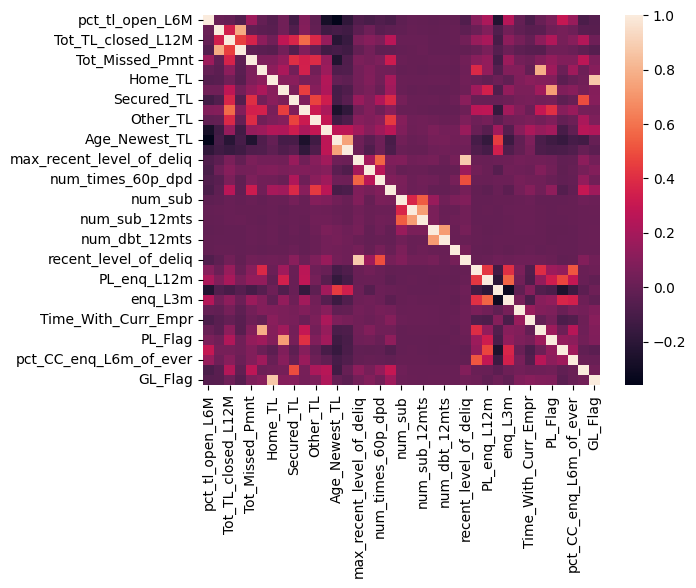

In [39]:
sns.heatmap(df_corr)

## univariate analysis:



In [40]:
# lets plot all the indivisulas which are more imp for predicting the approved flag

In [41]:
df_cleaned.columns

Index(['pct_tl_open_L6M', 'pct_tl_closed_L6M', 'Tot_TL_closed_L12M',
       'pct_tl_closed_L12M', 'Tot_Missed_Pmnt', 'CC_TL', 'Home_TL', 'PL_TL',
       'Secured_TL', 'Unsecured_TL', 'Other_TL', 'Age_Oldest_TL',
       'Age_Newest_TL', 'time_since_recent_payment',
       'max_recent_level_of_deliq', 'num_deliq_6_12mts', 'num_times_60p_dpd',
       'num_std_12mts', 'num_sub', 'num_sub_6mts', 'num_sub_12mts', 'num_dbt',
       'num_dbt_12mts', 'num_lss', 'recent_level_of_deliq', 'CC_enq_L12m',
       'PL_enq_L12m', 'time_since_recent_enq', 'enq_L3m', 'MARITALSTATUS',
       'EDUCATION', 'GENDER', 'NETMONTHLYINCOME', 'Time_With_Curr_Empr',
       'CC_Flag', 'PL_Flag', 'pct_PL_enq_L6m_of_ever',
       'pct_CC_enq_L6m_of_ever', 'HL_Flag', 'GL_Flag', 'last_prod_enq2',
       'first_prod_enq2', 'Approved_Flag'],
      dtype='object')

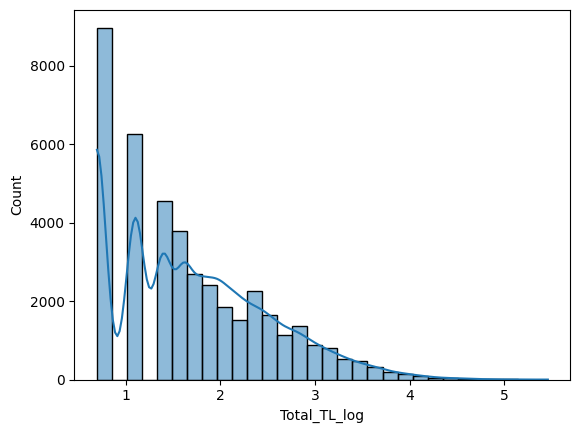

In [42]:
df_cleaned['Total_TL'] = df_cleaned[['CC_TL','Home_TL','PL_TL',
                                     'Secured_TL','Unsecured_TL','Other_TL']].sum(axis=1)
df_cleaned['Total_TL_log'] = np.log1p(df_cleaned['Total_TL'])
sns.histplot(data=df_cleaned, x='Total_TL_log', bins=30, kde=True)
df_cleaned=df_cleaned.drop('Total_TL_log',axis=1)

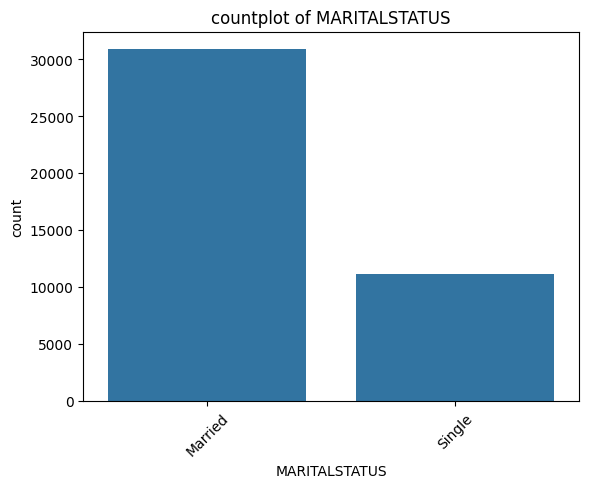

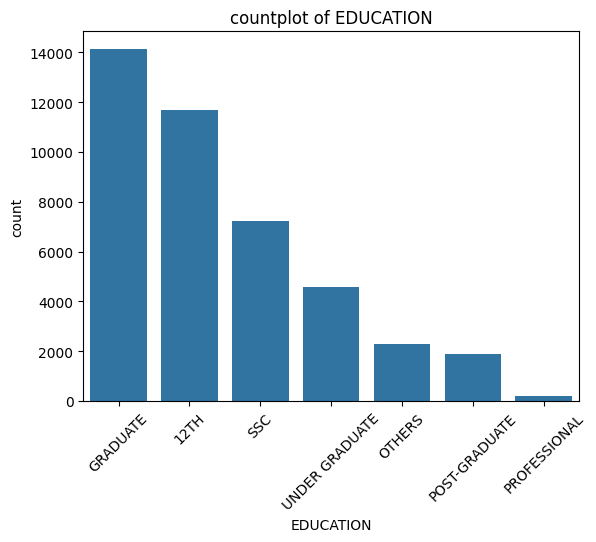

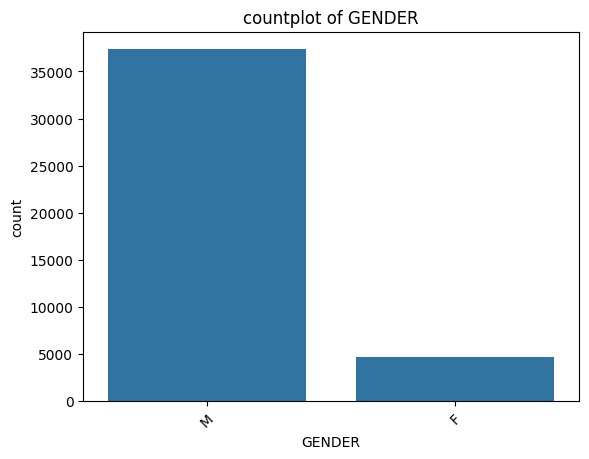

In [43]:
for col in ['MARITALSTATUS','EDUCATION', 'GENDER']:
    # plt.figure(figsize=(8,5))
    sns.countplot(data=df_cleaned,x=col,order=df[col].value_counts(ascending=False).index)
    plt.title(f"countplot of {col}")
    plt.xticks(rotation=45)
    plt.show()

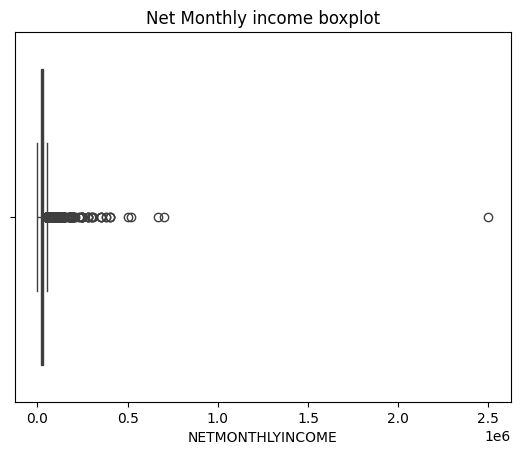

In [44]:
sns.boxplot(x=df_cleaned['NETMONTHLYINCOME'])
plt.title("Net Monthly income boxplot")
plt.show()

In [45]:
# removing the outliers by capping from the partucular value 
df_cleaned=df_cleaned[df_cleaned['NETMONTHLYINCOME']<=400000]

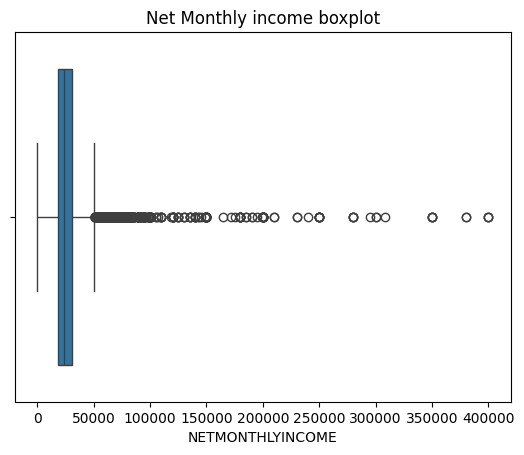

In [46]:
sns.boxplot(x=df_cleaned['NETMONTHLYINCOME'])
plt.title("Net Monthly income boxplot")
plt.show()

<Axes: xlabel='NETMONTHLYINCOME', ylabel='Count'>

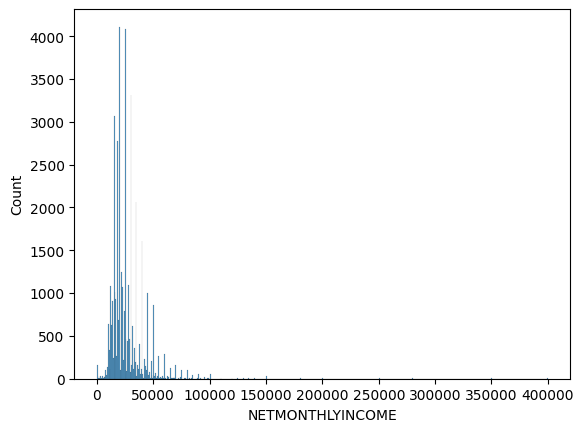

In [47]:
sns.histplot(x=df_cleaned['NETMONTHLYINCOME'])

<Axes: xlabel='Approved_Flag', ylabel='count'>

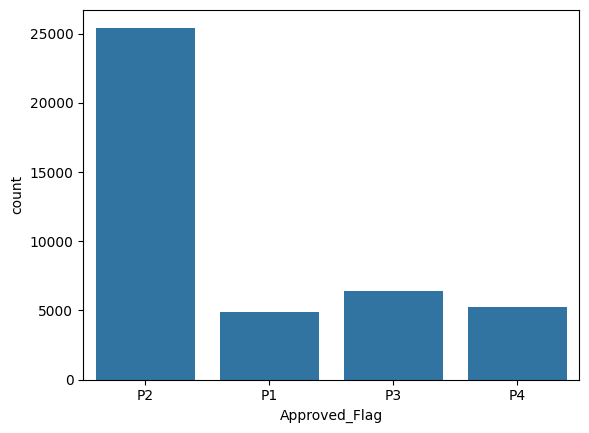

In [48]:
sns.countplot(data=df_cleaned,x='Approved_Flag')


#### insights
the total number TL's is under 4

most of the customers are `male` , `married ` and with education of `Graduate` and `12th` passed

most of the customers having monthly income <100000

and also there is imbalanced distribution of target

## Bivariate analysis

In [49]:
df_cleaned.columns

Index(['pct_tl_open_L6M', 'pct_tl_closed_L6M', 'Tot_TL_closed_L12M',
       'pct_tl_closed_L12M', 'Tot_Missed_Pmnt', 'CC_TL', 'Home_TL', 'PL_TL',
       'Secured_TL', 'Unsecured_TL', 'Other_TL', 'Age_Oldest_TL',
       'Age_Newest_TL', 'time_since_recent_payment',
       'max_recent_level_of_deliq', 'num_deliq_6_12mts', 'num_times_60p_dpd',
       'num_std_12mts', 'num_sub', 'num_sub_6mts', 'num_sub_12mts', 'num_dbt',
       'num_dbt_12mts', 'num_lss', 'recent_level_of_deliq', 'CC_enq_L12m',
       'PL_enq_L12m', 'time_since_recent_enq', 'enq_L3m', 'MARITALSTATUS',
       'EDUCATION', 'GENDER', 'NETMONTHLYINCOME', 'Time_With_Curr_Empr',
       'CC_Flag', 'PL_Flag', 'pct_PL_enq_L6m_of_ever',
       'pct_CC_enq_L6m_of_ever', 'HL_Flag', 'GL_Flag', 'last_prod_enq2',
       'first_prod_enq2', 'Approved_Flag', 'Total_TL'],
      dtype='object')

<Axes: xlabel='Approved_Flag', ylabel='Tot_Missed_Pmnt'>

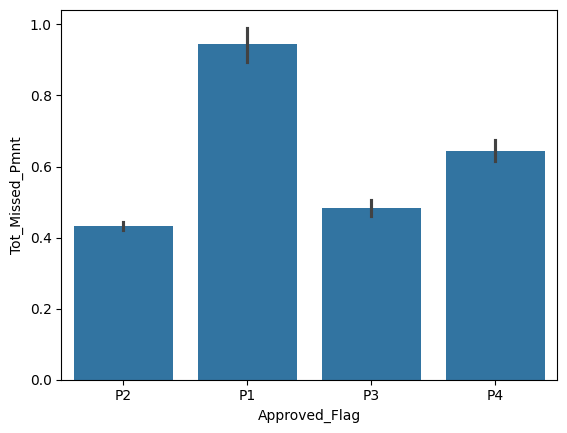

In [50]:
sns.barplot(data=df_cleaned,x='Approved_Flag',y='Tot_Missed_Pmnt')

<Axes: xlabel='Approved_Flag', ylabel='Tot_TL_closed_L12M'>

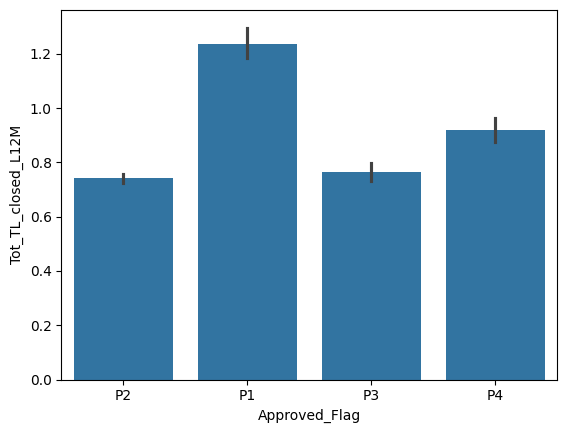

In [51]:
sns.barplot(data=df_cleaned,x='Approved_Flag',y='Tot_TL_closed_L12M')


<Axes: xlabel='Approved_Flag', ylabel='Age_Newest_TL'>

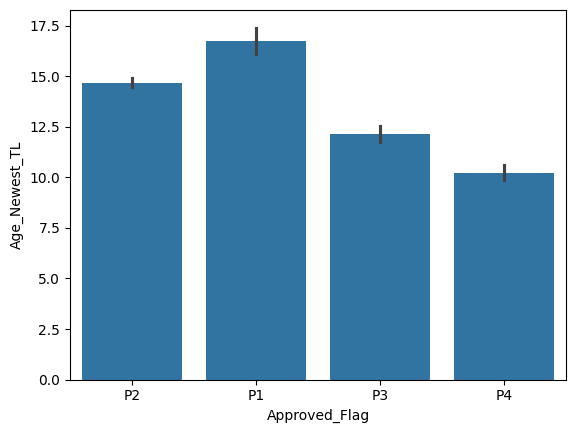

In [52]:
sns.barplot(data=df_cleaned,x='Approved_Flag',y='Age_Newest_TL')


In [53]:
## Multivariate analysis

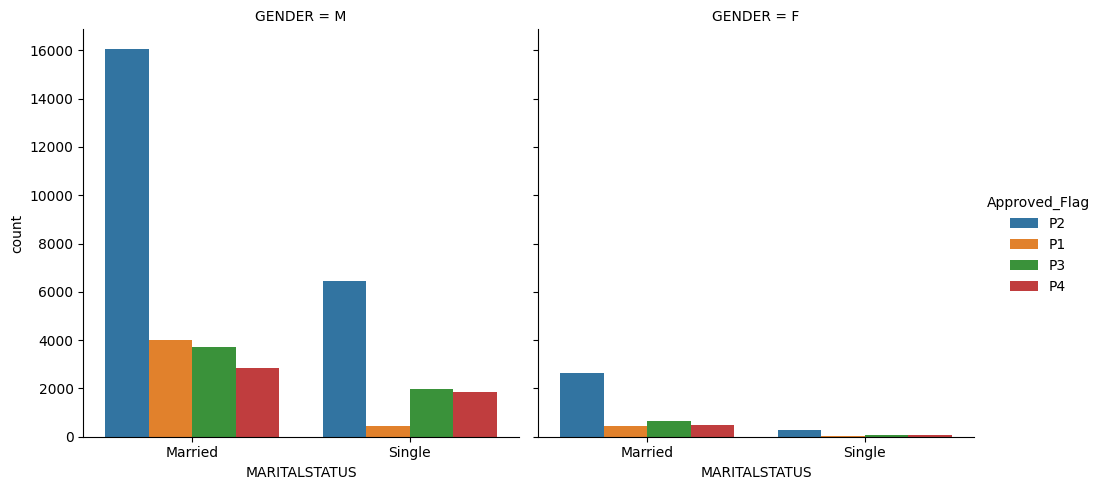

In [54]:
sns.catplot(x='MARITALSTATUS', hue='Approved_Flag', col='GENDER',
            kind='count', data=df_cleaned)


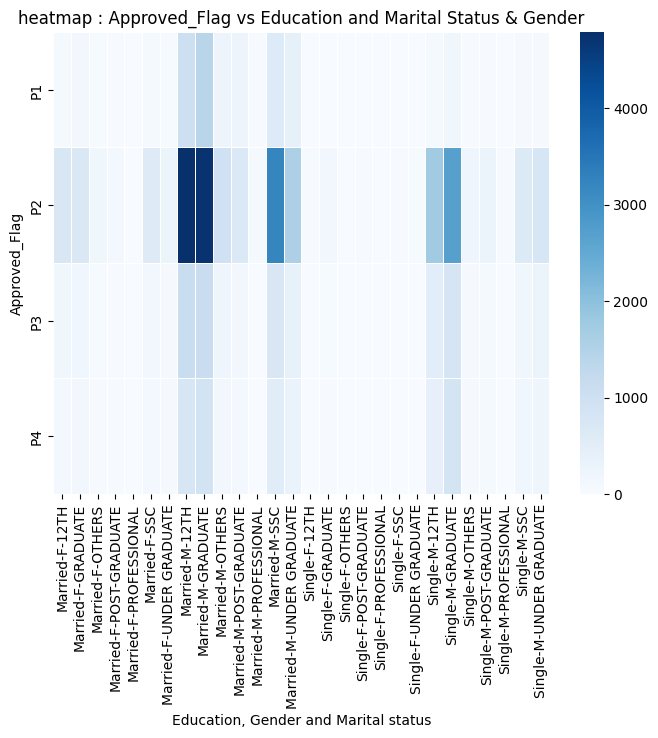

In [55]:

heat = pd.crosstab(
    index=df_cleaned['Approved_Flag'], 
    columns=[df_cleaned['MARITALSTATUS'], df_cleaned['GENDER'],df_cleaned['EDUCATION']], 
    # normalize='index'
)

plt.figure(figsize=(8, 6))
sns.heatmap(heat, cmap="Blues", fmt=".2f", linewidths=.5)

plt.title('heatmap : Approved_Flag vs Education and Marital Status & Gender')
plt.xlabel('Education, Gender and Marital status')
plt.ylabel('Approved_Flag')
plt.show()   

### now make the data model ready (i.e encoding features)

In [56]:
# lets ready categorical features first


for col in cat_cols:
    print(df_cleaned[col].value_counts())
    print()

MARITALSTATUS
Married    30881
Single     11178
Name: count, dtype: int64

EDUCATION
GRADUATE          14137
12TH              11703
SSC                7240
UNDER GRADUATE     4572
OTHERS             2291
POST-GRADUATE      1897
PROFESSIONAL        219
Name: count, dtype: int64

GENDER
M    37341
F     4718
Name: count, dtype: int64

last_prod_enq2
ConsumerLoan    16479
others          13650
PL               7553
CC               2195
AL               1352
HL                830
Name: count, dtype: int64

first_prod_enq2
others          20637
ConsumerLoan    11075
PL               4431
AL               2639
CC               1988
HL               1289
Name: count, dtype: int64

Approved_Flag
P2    25450
P3     6439
P4     5263
P1     4907
Name: count, dtype: int64



lets apply label encoder to target col

ordinal_encoder to Education col

and apply OHE to all other ()

In [57]:

df_cleaned.loc[df['EDUCATION'] == 'SSC', ['EDUCATION' ]]=1
df_cleaned.loc[df['EDUCATION'] == '12TH', ['EDUCATION' ]]=2
df_cleaned.loc[df['EDUCATION'] == 'GRADUATE', ['EDUCATION' ]]=3
df_cleaned.loc[df['EDUCATION'] == 'UNDER GRADUATE', [ 'EDUCATION' ]]=3
df_cleaned.loc[df['EDUCATION'] == 'POST-GRADUATE', [ 'EDUCATION' ]]=4
df_cleaned.loc[df['EDUCATION'] == 'PROFESSIONAL', [ 'EDUCATION' ]]=3
df_cleaned.loc[df['EDUCATION'] == 'OTHERS', [ 'EDUCATION' ]]=1

df_cleaned["EDUCATION"]=df_cleaned["EDUCATION"].astype(int)
df_cleaned["EDUCATION"].value_counts()


EDUCATION
3    18928
2    11703
1     9531
4     1897
Name: count, dtype: int64

In [58]:
# OHE

df_encoded=pd.get_dummies(df_cleaned,columns=['first_prod_enq2','last_prod_enq2','MARITALSTATUS','GENDER'])

In [59]:
df_encoded.head()

,pct_tl_open_L6M,pct_tl_closed_L6M,Tot_TL_closed_L12M,pct_tl_closed_L12M,Tot_Missed_Pmnt,CC_TL,Home_TL,PL_TL,Secured_TL,Unsecured_TL,...,last_prod_enq2_AL,last_prod_enq2_CC,last_prod_enq2_ConsumerLoan,last_prod_enq2_HL,last_prod_enq2_PL,last_prod_enq2_others,MARITALSTATUS_Married,MARITALSTATUS_Single,GENDER_F,GENDER_M
0,0.000,0.0,0,0.000,0,0,0,4,1,4,...,False,False,False,False,True,False,True,False,False,True
1,0.000,0.0,0,0.000,0,0,0,0,0,1,...,False,False,True,False,False,False,False,True,True,False
2,0.125,0.0,0,0.000,1,0,0,0,2,6,...,False,False,True,False,False,False,True,False,False,True
3,0.000,0.0,0,0.000,0,0,0,0,3,0,...,True,False,False,False,False,False,True,False,False,True
4,0.000,0.0,1,0.167,0,0,0,0,6,0,...,False,False,True,False,False,False,True,False,False,True


In [60]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 42059 entries, 0 to 42063
Data columns (total 56 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   pct_tl_open_L6M               42059 non-null  float64
 1   pct_tl_closed_L6M             42059 non-null  float64
 2   Tot_TL_closed_L12M            42059 non-null  int64  
 3   pct_tl_closed_L12M            42059 non-null  float64
 4   Tot_Missed_Pmnt               42059 non-null  int64  
 5   CC_TL                         42059 non-null  int64  
 6   Home_TL                       42059 non-null  int64  
 7   PL_TL                         42059 non-null  int64  
 8   Secured_TL                    42059 non-null  int64  
 9   Unsecured_TL                  42059 non-null  int64  
 10  Other_TL                      42059 non-null  int64  
 11  Age_Oldest_TL                 42059 non-null  int64  
 12  Age_Newest_TL                 42059 non-null  int64  
 13  time_s

In [61]:
from sklearn.preprocessing import LabelEncoder,OneHotEncoder
from sklearn.model_selection import train_test_split

X=df_encoded.drop('Approved_Flag',axis=1)
y=df_encoded['Approved_Flag']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,stratify=y)

<Axes: xlabel='Approved_Flag'>

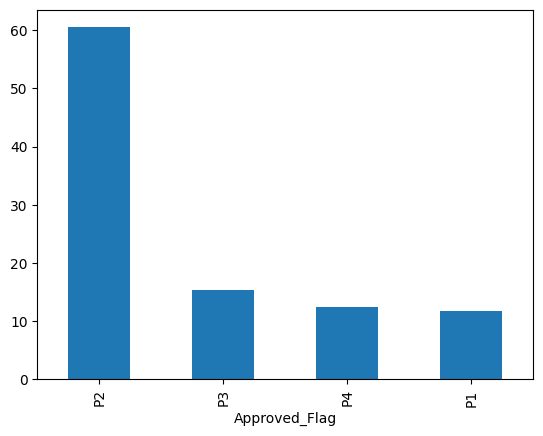

In [62]:
(y.value_counts(normalize=True)*100).plot(kind='bar')

In [63]:
# here there is imabalanced btw category so we can try SMOTE in future if model does not perform well

## Decision trees

In [64]:
from sklearn.metrics import precision_recall_fscore_support,accuracy_score
from sklearn.tree import DecisionTreeClassifier

In [65]:
dt_clf=DecisionTreeClassifier(max_depth=20,min_samples_split=10)
dt_clf.fit(X_train,y_train)
y_pred_dt=dt_clf.predict(X_test)

In [69]:
def evaluation_report(y_test,y_pred):
    accuracy=accuracy_score(y_test,y_pred)
    print(f"accuracy: {accuracy}")
    print()
    precision,recall,f1_score,_=precision_recall_fscore_support(y_test,y_pred)
    
    for i,v in enumerate(['P1','P2','P3','P4']):
        print(f"for {v}")
        print(f"precision :{precision[i]}")
        print(f"recall :{recall[i]}")
        print(f"f1_score :{f1_score[i]}")
        print()
evaluation_report(y_test,y_pred_dt)


accuracy: 0.7158028213663021

for P1
precision :0.7151238591916558
recall :0.7452445652173914
f1_score :0.7298735861610113

for P2
precision :0.8139204545454546
recall :0.8255402750491159
f1_score :0.8196891865530919

for P3
precision :0.3481848184818482
recall :0.327639751552795
f1_score :0.3376

for P4
precision :0.6563731931668857
recall :0.6326789107029765
f1_score :0.6443082876491454



## RandomForestClassifier

In [70]:
from sklearn.ensemble import RandomForestClassifier

rf=RandomForestClassifier(n_estimators=200,max_depth=20,min_samples_split=10,class_weight='balanced')
rf.fit(X_train,y_train)
y_pred_rf=rf.predict(X_test)
evaluation_report(y_test,y_pred_rf)
          


accuracy: 0.7534474560152163

for P1
precision :0.7182190978324546
recall :0.8328804347826086
f1_score :0.7713117332494495

for P2
precision :0.8648350131161121
recall :0.8204322200392927
f1_score :0.842048662454631

for P3
precision :0.4234475374732334
recall :0.40942028985507245
f1_score :0.4163157894736842

for P4
precision :0.6811111111111111
recall :0.7764407853071564
f1_score :0.7256584788398934



## XGBoost

In [72]:
import xgboost as xgb

label_map={'P1':0,'P2':1,'P3':2,'P4':3}

y_train_en=y_train.map(label_map)
y_test_en=y_test.map(label_map)

xgb_clf = xgb.XGBClassifier(
    n_estimators=500,
    objective="multi:softmax", 
    learning_rate=0.05,
    max_depth=10,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,  
    reg_lambda=1.0,
)
xgb_clf.fit(X_train, y_train_en)
y_pred_xgb= xgb_clf.predict(X_test)
evaluation_report(y_test_en,y_pred_xgb)



accuracy: 0.7771437628784277

for P1
precision :0.8053408292340126
recall :0.7785326086956522
f1_score :0.7917098445595855

for P2
precision :0.8219274562742106
recall :0.9170923379174852
f1_score :0.8669060294663861

for P3
precision :0.45036764705882354
recall :0.2536231884057971
f1_score :0.32450331125827814

for P4
precision :0.7355163727959698
recall :0.7397086763774541
f1_score :0.7376065677297127

